# Pramana — describe an experiment, run it, see the results

Pramana turns a plain-English description of a network experiment into a real,
measured run. You write **one sentence** describing what you want (the app, the
link speed, the latency, how long, and so on), and Pramana figures out the rest:
it configures the network, runs the application, captures the traffic, and records
the throughput and latency it actually measured.

**How to use this notebook:**

1. Edit the `INTENT` sentence in the next cell to describe your experiment.
2. Run the **Run experiment** cell and wait for the summary.
3. Run the **Show history** cell to see past experiments.

That's it, no network, API, or programming knowledge required.

In [68]:
import importlib, pramana_helpers  # noqa: E401
importlib.reload(pramana_helpers)
from pramana_helpers import *  # loads the services and helper functions

# Describe your experiment in plain English:
INTENT = (
    "Run YouTube, Twitch, and Tubi at the same time on a 6 Mbps bottleneck with "
    "50 ms latency for 60 seconds using cubic congestion control and a pfifo queue."
)

# Optional — pin exact values by describing them in the sentence above.
# Examples you can write in plain English inside INTENT:
#   capacity:          "on a 10 Mbps link"
#   latency:           "with 20 ms latency"
#   congestion control:"using bbr"  (cubic / bbr / reno)
#   queue / AQM:       "with an fq_codel queue"  (pfifo / fq_codel / codel)
#   duration:          "for 90 seconds"
#   repeats:           "repeat 3 times"
#   concurrent apps:   "run YouTube and Zoom at the same time"

## Run experiment

In [69]:
run_and_display(INTENT)

Submitting intent to Pramana ...
  orchestration_id: orch-a963e524
  running (shaping + capture + transfer can take a few minutes) ...
  pending ... (0s)
  generating ... (5s)
  executing ... (10s)
  complete ... (147s)

✓ Experiment complete
  App:        youtube+twitch+tubi
  Capacity:   6 Mbps
  Latency:    50 ms
  Throughput: n/a
  RTT:        n/a
  (metrics not yet available)


## Show history

In [70]:
show_history()

15 most recent experiment(s) in telemetry:


,when,app,status,capacity (Mbps),latency (ms),throughput (Mbps),rtt (ms)
0,2026-07-08 07:36:16,youtube,success,6,50,6.2141,20.007
1,2026-07-08 07:32:14,youtube,success,6,50,6.2399,7.709
2,2026-07-08 07:23:17,youtube,success,6,50,6.1436,3.264
3,2026-07-08 07:20:42,youtube,success,6,50,6.2268,181.626
4,2026-07-08 06:45:03,youtube+twitch,success,6,50,0,n/a
5,2026-07-06 21:27:39,youtube,success,6,50,6.2343,298.976
6,2026-07-06 19:35:29,youtube,success,6,50,6.1445,282.828
7,2026-07-06 19:30:16,wget,success,10,20,10.3715,128.433
8,2026-07-06 19:08:36,youtube,success,6,50,6.1938,238.001
9,2026-07-06 19:04:34,youtube,success,6,50,6.1389,426.244


,when,app,status,capacity (Mbps),latency (ms),throughput (Mbps),rtt (ms)
0,2026-07-08 07:36:16,youtube,success,6,50,6.2141,20.007
1,2026-07-08 07:32:14,youtube,success,6,50,6.2399,7.709
2,2026-07-08 07:23:17,youtube,success,6,50,6.1436,3.264
3,2026-07-08 07:20:42,youtube,success,6,50,6.2268,181.626
4,2026-07-08 06:45:03,youtube+twitch,success,6,50,0,n/a
5,2026-07-06 21:27:39,youtube,success,6,50,6.2343,298.976
6,2026-07-06 19:35:29,youtube,success,6,50,6.1445,282.828
7,2026-07-06 19:30:16,wget,success,10,20,10.3715,128.433
8,2026-07-06 19:08:36,youtube,success,6,50,6.1938,238.001
9,2026-07-06 19:04:34,youtube,success,6,50,6.1389,426.244


## Time-series plots

Reads the PCAP captured for the run (from `/tmp/substrate-capture/`) with Scapy and draws:

- **Throughput over time** — one line per app, separated by remote server IP, with the 6 Mbps cap marked in red.
- **Queue depth over time** — from the qtrace JSONL captured alongside the PCAP.

Both PNGs are saved next to the PCAP and shown inline.

In [72]:
import sys
!{sys.executable} -m pip install scapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 12.0 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip



Experiment: youtube+twitch+tubi_6_6_50_pfifo_cubic_0a8a097e
  pcap: /tmp/substrate-capture/youtube+twitch+tubi_6_6_50_pfifo_cubic_0a8a097e.pcap


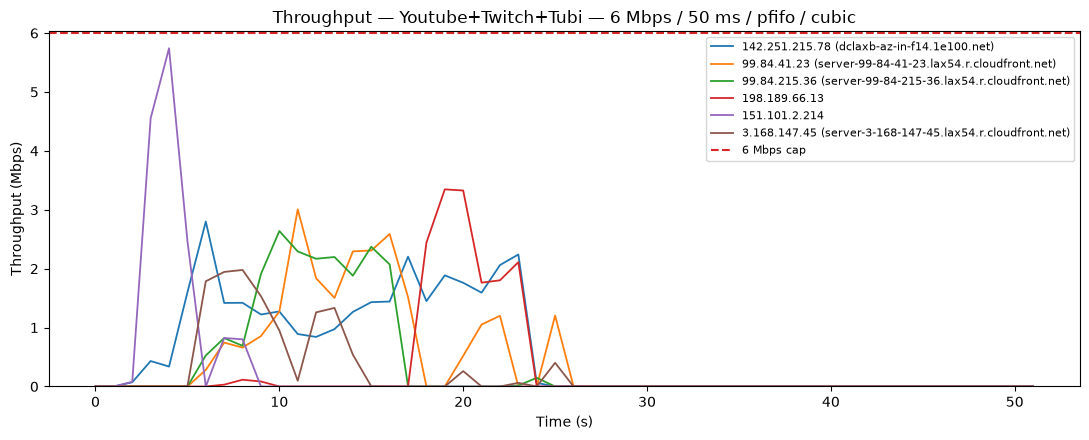

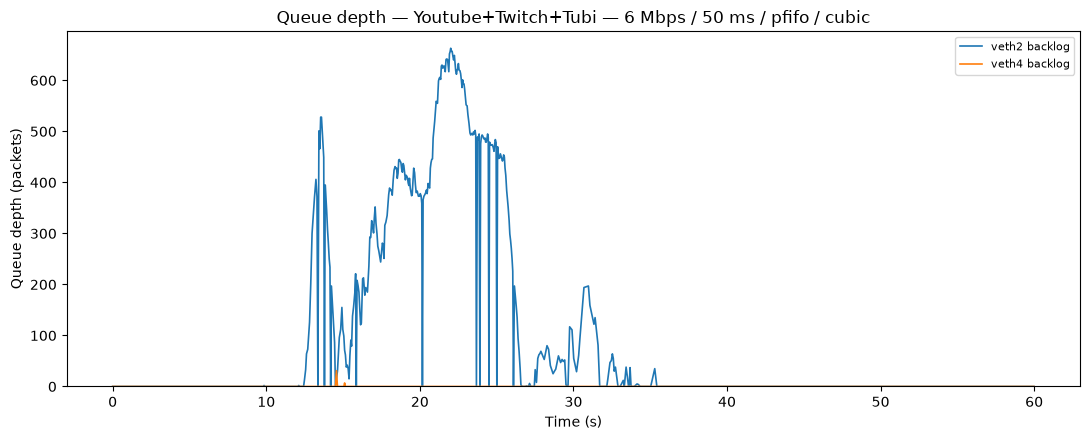


Saved:
  /tmp/substrate-capture/youtube+twitch+tubi_6_6_50_pfifo_cubic_0a8a097e_throughput.png
  /tmp/substrate-capture/youtube+twitch+tubi_6_6_50_pfifo_cubic_0a8a097e_queue_depth.png


['/tmp/substrate-capture/youtube+twitch+tubi_6_6_50_pfifo_cubic_0a8a097e_throughput.png',
 '/tmp/substrate-capture/youtube+twitch+tubi_6_6_50_pfifo_cubic_0a8a097e_queue_depth.png']

In [73]:
plot_experiment()